In [1]:
import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)
sns.set_theme(style="whitegrid")

## Task 1: One-Sample t-Test

**Scenario:** A coffee-shop chain claims that the average wait time at their stores is 4.0 minutes. You have collected wait times (in minutes) from a random sample of 35 visits.

### 1. Generate the sample data

In [2]:
wait_times = np.random.normal(loc=4.3, scale=1.2, size=35)
print(f"Sample Mean: {np.mean(wait_times):.4f}")

Sample Mean: 4.1408


### 2. State the null and alternative hypotheses

- **Null Hypothesis ($H_0$):** $\mu = 4.0$ (The average wait time is 4.0 minutes)
- **Alternative Hypothesis ($H_1$):** $\mu \neq 4.0$ (The average wait time differs from 4.0 minutes)

### 3. Run the One-Sample t-Test

In [3]:
t_stat, p_value = st.ttest_1samp(wait_times, popmean=4.0)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: 0.7451
p-value: 0.4614


### 4. Decision and Interpretation

**Decision:** At $\alpha = 0.05$, since the p-value ($0.4614$) is greater than $0.05$, we **fail to reject** the null hypothesis.

**Interpretation:** There is not sufficient evidence to suggest that the average wait time differs from 4 minutes.

## Task 2: Independent Two-Sample t-Test

**Scenario:** An e-commerce company ran an A/B test on its checkout page. Group A (control, n = 50) saw the old design; Group B (treatment, n = 50) saw a streamlined design. The metric is order value in euros.

### 1. Generate the data

In [4]:
group_a = np.random.normal(loc=52, scale=12, size=50)
group_b = np.random.normal(loc=57, scale=14, size=50)

print(f"Group A Mean: {np.mean(group_a):.4f}, Variance: {np.var(group_a, ddof=1):.4f}")
print(f"Group B Mean: {np.mean(group_b):.4f}, Variance: {np.var(group_b, ddof=1):.4f}")

Group A Mean: 50.8057, Variance: 136.0601
Group B Mean: 56.3917, Variance: 169.2537


### 2. State the hypotheses

- **Null Hypothesis ($H_0$):** $\mu_A = \mu_B$ (The mean order values are equal)
- **Alternative Hypothesis ($H_1$):** $\mu_A \neq \mu_B$ (The mean order values are not equal)

### 3. Check Assumption: Equal Variance (Levene's Test)

In [5]:
l_stat, p_levene = st.levene(group_a, group_b)
print(f"Levene's test p-value: {p_levene:.4f}")

Levene's test p-value: 0.7096


### 4. Run the Independent Two-Sample t-Test

Since the Levene's test p-value ($0.7096$) is greater than $0.05$, we assume **equal variances** ($equal\_var=True$).

In [6]:
t_stat, p_value = st.ttest_ind(group_a, group_b, equal_var=True)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: -2.2605
p-value: 0.0260


### 5. Decision and Interpretation

**Decision:** At $\alpha = 0.05$, since the p-value ($0.0260$) is less than $0.05$, we **reject** the null hypothesis.

**Interpretation:** There is sufficient evidence that the average order value differs between the two designs. Specifically, the streamlined design (Group B) appears to have a higher average order value.

## Task 3: Paired t-Test

**Scenario:** A company measures employee productivity scores before and after a new workflow tool is introduced. The same 30 employees are measured at both time points.

### 1. Generate the paired data

In [7]:
before = np.random.normal(loc=70, scale=8, size=30)
after = before + np.random.normal(loc=3, scale=5, size=30)

df_paired = pd.DataFrame({'Before': before, 'After': after, 'Difference': after - before})
df_paired.head()

,Before,After,Difference
0,82.399475,87.463380,5.063905
1,63.733974,70.844274,7.110301
2,67.423508,79.907473,12.483965
3,76.508138,78.281197,1.773059
4,60.153085,59.384405,-0.768681


### 2. State the hypotheses

We will use a **two-tailed test** to see if there is any change in productivity, although a one-tailed test could be justified if we specifically expected an improvement.

- **Null Hypothesis ($H_0$):** $\mu_{diff} = 0$ (The mean difference in productivity is zero)
- **Alternative Hypothesis ($H_1$):** $\mu_{diff} \neq 0$ (The mean difference in productivity is not zero)

### 3. Inspect Differences

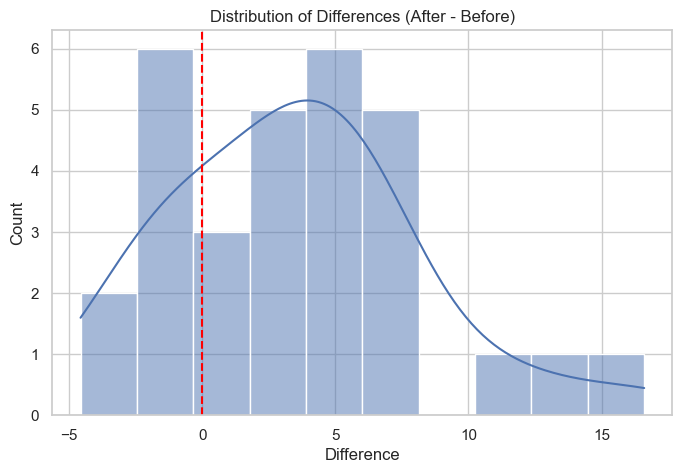

In [8]:
plt.figure(figsize=(8, 5))
sns.histplot(df_paired['Difference'], kde=True, bins=10)
plt.title("Distribution of Differences (After - Before)")
plt.axvline(0, color='red', linestyle='--')
plt.show()

### 4. Run the Paired t-Test

In [9]:
t_stat, p_value = st.ttest_rel(after, before)
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value:.4f}")

t-statistic: 4.0792
p-value: 0.0003


### 5. Decision and Interpretation

**Decision:** At $\alpha = 0.05$, since the p-value ($0.0003$) is much less than $0.05$, we **reject** the null hypothesis.

**Interpretation:** There is strong evidence that the productivity scores significantly changed after the introduction of the new workflow tool.

## Task 4: Bonus - Permutation Test

To fulfill the learning goal of implementing a permutation test, we will re-evaluate the Task 2 (Independent Two-Sample) result using a non-parametric approach.

In [10]:
def permutation_test(data1, data2, n_permutations=10000):
    obs_diff = np.abs(np.mean(data1) - np.mean(data2))
    combined = np.concatenate([data1, data2])
    count = 0
    
    for _ in range(n_permutations):
        np.random.shuffle(combined)
        new_data1 = combined[:len(data1)]
        new_data2 = combined[len(data1):]
        new_diff = np.abs(np.mean(new_data1) - np.mean(new_data2))
        if new_diff >= obs_diff:
            count += 1
            
    return count / n_permutations

p_perm = permutation_test(group_a, group_b)
print(f"Permutation Test p-value: {p_perm:.4f}")
print(f"Classical t-test p-value: 0.0260")

Permutation Test p-value: 0.0266
Classical t-test p-value: 0.0260
